In [23]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import xarray as xr
from pathlib import Path
import importlib

# ocean_analysis.py in OGGCM/scripts
NB_DIR = Path.cwd()
OCEAN_SCRIPT_DIR = NB_DIR.parents[1] / "OGCM" / "scripts"
if str(OCEAN_SCRIPT_DIR) not in sys.path:
    sys.path.append(str(OCEAN_SCRIPT_DIR))

import ocean_analysis as oa
importlib.reload(oa)

<module 'ocean_analysis' from 'c:\\Users\\Jelle Gortemaker\\Documents\\Thesis\\OGCM\\scripts\\ocean_analysis.py'>

<xarray.Dataset> Size: 118MB
Dimensions:      (Zmd000001: 1, T: 28, Y: 512, Xp1: 513, Yp1: 513, X: 512,
                  Zld000001: 1)
Coordinates:
  * T            (T) float64 224B 0.0 4.32e+04 8.64e+04 ... 1.123e+06 1.166e+06
  * Y            (Y) float64 4kB 250.0 750.0 1.25e+03 ... 2.552e+05 2.558e+05
  * Xp1          (Xp1) float64 4kB 0.0 500.0 1e+03 ... 2.555e+05 2.56e+05
  * Yp1          (Yp1) float64 4kB 0.0 500.0 1e+03 ... 2.555e+05 2.56e+05
  * X            (X) float64 4kB 250.0 750.0 1.25e+03 ... 2.552e+05 2.558e+05
Dimensions without coordinates: Zmd000001, Zld000001
Data variables:
    diag_levels  (Zmd000001) float64 8B ...
    iter         (T) int32 112B ...
    UVEL         (T, Zmd000001, Y, Xp1) float32 29MB ...
    VVEL         (T, Zmd000001, Yp1, X) float32 29MB ...
    WVEL         (T, Zld000001, Y, X) float32 29MB ...
    momVort3     (T, Zmd000001, Yp1, Xp1) float32 29MB ...
Attributes: (12/18)
    MITgcm_version:  checkpoint69l
    build_user:      jgortemaker
  

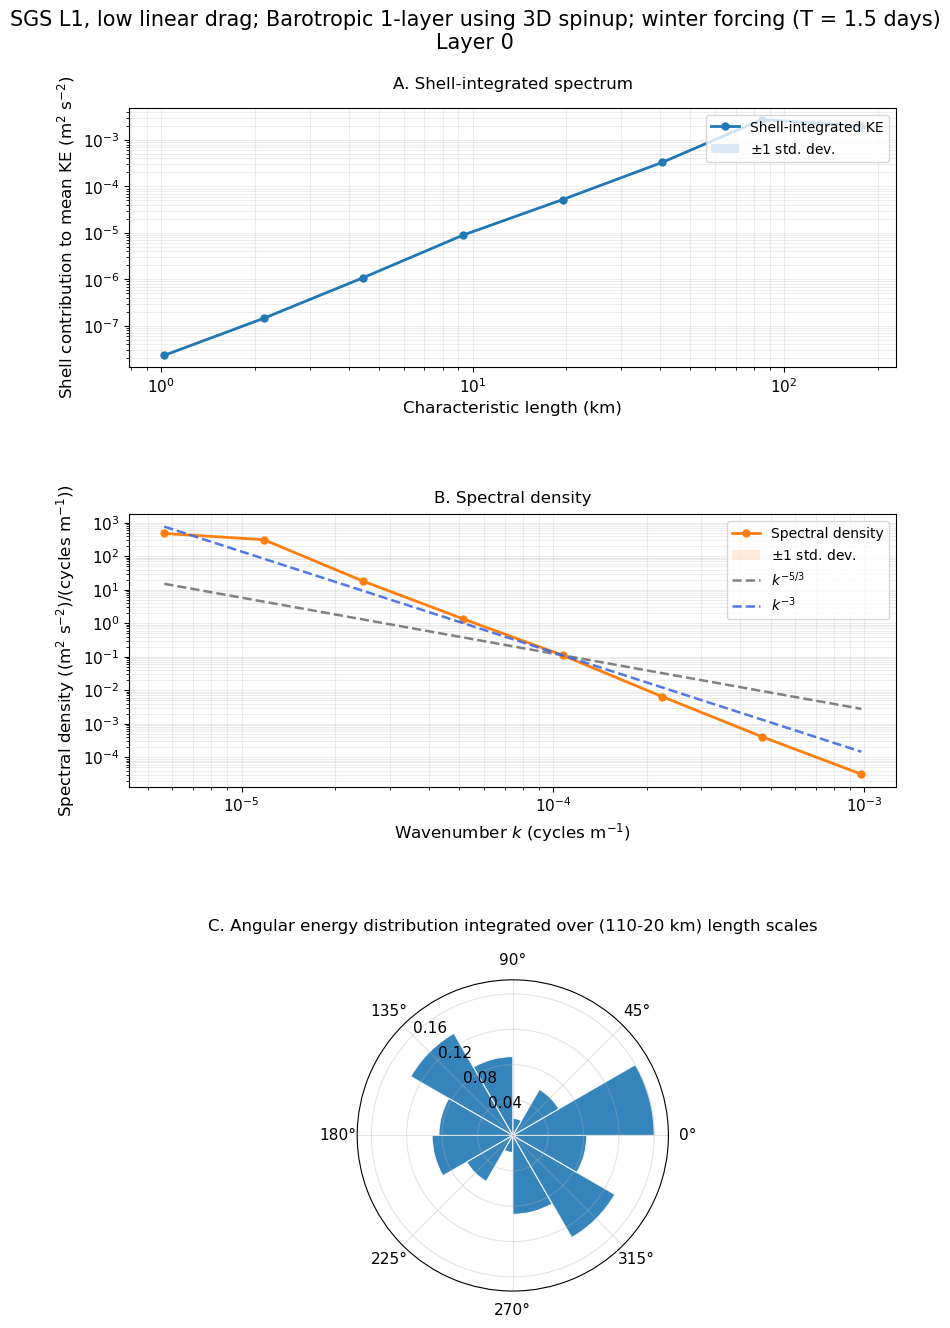

In [26]:
case_name = "run_baro_spinup_sea_win_lindraglow_L1"
sim_name = "SGS L1, low linear drag; Barotropic 1-layer using 3D spinup; winter forcing"
SAVE = True

DATA_FILE = (NB_DIR / f"../data/input/{case_name}.nc").resolve()

eds_init = oa.calculate_EDS_init(
    DATA_FILE,
    target_box=None,
    max_wavelength_km=None,
    x_res=500,
    y_res=500,
    n_bins=8,
    remove_mean=True,
    min_modes_per_bin=3,
    rose_scale_bands_km=[(110, 20)],
    rose_n_angle_bins=12,
    snapshot_index=3,
    layer_index=0,
)


if eds_init.attrs['snapshot_time_index'] is not None:
    n_days = eds_init.attrs['snapshot_time_index'] / 2
    title = f"{sim_name} (T = {n_days} days)"
else:
    title = f"{sim_name}"
oa.plot_eds_overview(eds_init, title=title)


results_dir = (NB_DIR / f"../results/{case_name}").resolve()
results_dir.mkdir(parents=True, exist_ok=True)
if SAVE:=True:
    plt.savefig(f"{results_dir}/{case_name}_T{eds_init.attrs['snapshot_time_index']}_EDS_overview.png", dpi=300, bbox_inches="tight")
